## Laboratorio 5 - Umbralización de Otsu

Implementación manual de la umbralización de Otsu usando la fórmula de la varianza inter-clases:

$$ \sigma_{b}^{2}(t) = w_0(t) w_1(t) (\mu_0(t) - \mu_1(t))^2 $$

Donde:
- $w_0$ y $w_1$ son las probabilidades de ocurrir de ambas clases para un umbral $t$.
- $\mu_0$ y $\mu_1$ son las medias en intensidad de cada clase.

Umbral óptimo calculado manualmente (Otsu): 135


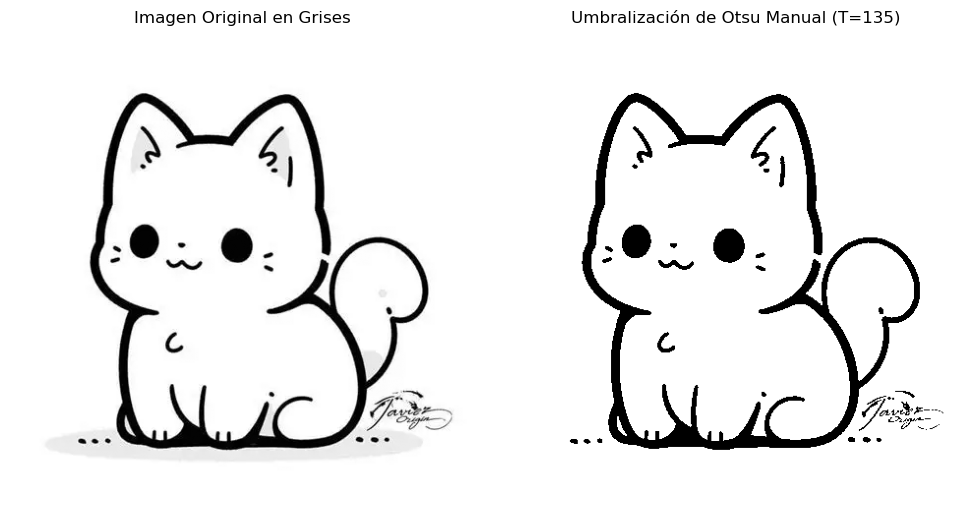

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def otsu_manual(image):
    # Calculamos el his
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    
    # Prob por niv
    total_pixels = image.shape[0] * image.shape[1]
    P = hist / total_pixels
    
    mejor_t = 0
    max_sigma_b2 = 0
    
    for t in range(256):
        w0 = np.sum(P[:t+1])
        w1 = np.sum(P[t+1:])
        
        if w0 == 0 or w1 == 0:
            continue
            
        mu0 = np.sum(np.arange(t+1) * P[:t+1]) / w0
        mu1 = np.sum(np.arange(t+1, 256) * P[t+1:]) / w1
        
        sigma_b2 = w0 * w1 * ((mu0 - mu1) ** 2)
        
        if sigma_b2 > max_sigma_b2:
            max_sigma_b2 = sigma_b2
            mejor_t = t
            
    return mejor_t

imagen = cv2.imread('gato.jpg', cv2.IMREAD_GRAYSCALE)

if imagen is not None:
    umbral_optimo_otsu = otsu_manual(imagen)
    print(f"Umbral óptimo calculado manualmente (Otsu): {umbral_optimo_otsu}")
    
    _, imagen_umbralizada = cv2.threshold(imagen, umbral_optimo_otsu, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title('Imagen Original en Grises')
    plt.imshow(imagen, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f'Umbralización de Otsu Manual (T={umbral_optimo_otsu})')
    plt.imshow(imagen_umbralizada, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: No se encontró la imagen 'gato.jpg'. Comprueba la ruta.")